<div style="display:flex;align-items:center;gap:18px;border-bottom:1px solid #d9d4ca;padding-bottom:18px">
  <img src="assets/belieflens-logo.png" width="86" alt="BeliefLens logo">
  <div><h1 style="margin:0">Verity public API</h1><p style="margin:5px 0 0;color:#0b7774;font-weight:700">Powered by the BeliefLens analytics engine</p></div>
</div>

This notebook shows how to call the fixed, keyless Verity service and turn its JSON response into an inspectable governance report. Verity generates an evidence-bounded answer; the BeliefLens analytics engine measures phrase support, sensitivity to equivalent prompt wording, dependence on supplied evidence, and claim-to-source attribution.

**Important:** these are uncalibrated, execution-specific diagnostics—not a factual-truth certificate or a reference posterior. For the mathematical construction, read [*Stochastic Semantic Evidence Graphs: Uncertainty Propagation and Governance for Agentic AI*](https://belieflens.org/assets/belieflens-stochastic-evidence-graphs-preprint.pdf).

## What you will do

1. Inspect the public quota before making a request.
2. Submit either supplied evidence or a web-grounded question.
3. Convert the nested response into claim- and source-level tables.
4. Visualize the annotated answer, uncertainty channels, and stochastic semantic evidence graph.
5. Use the same call as a LangChain or LangGraph node.
6. locate the corresponding OpenTelemetry trace in the protected Jaeger interface.

The included response fixture is a real, sanitized API result. `RUN_LIVE` is off by default, so reading the notebook consumes no public quota.

In [1]:
from pathlib import Path
import html
import json

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

BASE_URL = "https://demo.belieflens.org"
RUN_LIVE = False  # Change deliberately to True to spend one public request.

def locate(name):
    candidates = [Path(name), Path.cwd() / name, Path.cwd() / "engine/examples/notebooks/verity" / name,
                  Path.cwd() / "examples/notebooks/verity" / name]
    return next((path for path in candidates if path.exists()), None)


## 1. Inspect the service budget

The public interface has two independent protections: a rolling per-IP throttle and a persistent, aggregate UTC daily spend ledger. A distributed burst therefore cannot bypass the global daily cap. HTTP `429` means stop; the notebook does not retry automatically.

In [2]:
try:
    with httpx.Client(base_url=BASE_URL, timeout=30) as client:
        budget_response = client.get("/v1/seg/public-budget")
        budget_response.raise_for_status()
        budget = budget_response.json()
except httpx.HTTPError:
    fixture = locate("sample_verity_result.json")
    budget = json.loads(fixture.read_text()).get("public_budget", {}) if fixture else {}
    budget["note"] = "Live budget unavailable; showing the bundled run's ledger."
pd.Series(budget, name="Public Verity budget")


day_utc                              2026-09-04
limit_usd                                   3.0
debited_usd                                0.39
remaining_usd                              2.61
request_count                                 9
accounting       conservative pre-request debit
Name: Public Verity budget, dtype: object

## 2. Add a dated CSV time series as evidence

This example asks whether a historical credit-market episode justified heightened monitoring. The bundled CSV contains initial-release observations from ALFRED rather than revised values. The `available_by` field records when every value in a row was public, preserving the information boundary. This is an explanatory governance example, not a trading backtest.

Verity accepts bounded text passages rather than arbitrary files. The notebook therefore validates the CSV, displays and plots it, and converts each declared series into a separate, auditable evidence passage. The original rows remain visible and the stochastic semantic evidence graph preserves the three series as distinct source nodes.


,observation_date,available_by,baa_10y_spread_pct,aaa_10y_spread_pct,baa_minus_aaa_pct,nfci_credit_index
0,2020-02-28 00:00:00,2020-03-04 00:00:00,2.38,1.57,0.81,-0.77
1,2020-03-06 00:00:00,2020-03-11 00:00:00,2.55,1.62,0.93,-0.72
2,2020-03-13 00:00:00,2020-03-18 00:00:00,3.30,2.09,1.21,-0.60
3,2020-03-20 00:00:00,2020-03-25 00:00:00,4.23,3.20,1.03,-0.38
4,2020-03-27 00:00:00,2020-04-01 00:00:00,3.98,2.23,1.75,-0.22
5,2020-04-03 00:00:00,2020-04-08 00:00:00,3.92,2.01,1.91,-0.12
6,2020-04-10 00:00:00,2020-04-15 00:00:00,—,—,—,-0.11
7,2020-04-17 00:00:00,2020-04-22 00:00:00,3.27,1.76,1.51,-0.17
8,2020-04-24 00:00:00,2020-04-29 00:00:00,3.25,1.70,1.55,-0.22
9,2020-05-01 00:00:00,2020-05-06 00:00:00,3.25,1.78,1.47,-0.12


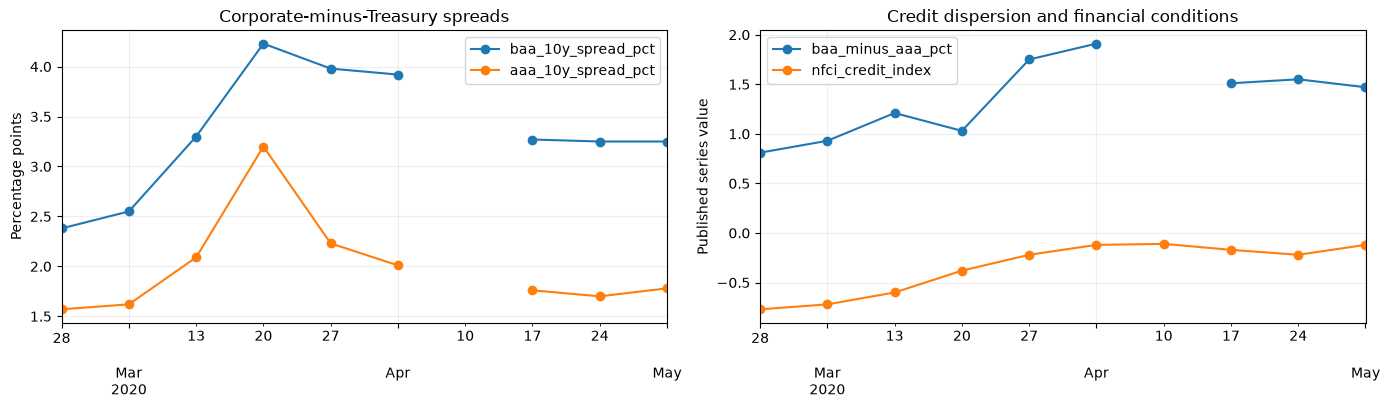

In [3]:
csv_path = locate("credit_market_timeseries.csv")
if csv_path is None:
    raise FileNotFoundError("Run from the repository root or this notebook directory.")

market = pd.read_csv(csv_path, parse_dates=["observation_date", "available_by"])
required = {
    "observation_date", "available_by", "baa_10y_spread_pct",
    "aaa_10y_spread_pct", "baa_minus_aaa_pct", "nfci_credit_index",
}
missing = required.difference(market.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")
if not market["observation_date"].is_monotonic_increasing:
    raise ValueError("The time series must be ordered by observation date.")
if (market["available_by"] < market["observation_date"]).any():
    raise ValueError("available_by cannot precede observation_date.")

display(market.style.format({
    "baa_10y_spread_pct": "{:.2f}",
    "aaa_10y_spread_pct": "{:.2f}",
    "baa_minus_aaa_pct": "{:.2f}",
    "nfci_credit_index": "{:.2f}",
}, na_rep="—"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
market.plot(x="observation_date", y=["baa_10y_spread_pct", "aaa_10y_spread_pct"], ax=axes[0], marker="o")
axes[0].set_title("Corporate-minus-Treasury spreads")
axes[0].set_ylabel("Percentage points")
axes[0].set_xlabel("")
market.plot(x="observation_date", y=["baa_minus_aaa_pct", "nfci_credit_index"], ax=axes[1], marker="o")
axes[1].set_title("Credit dispersion and financial conditions")
axes[1].set_ylabel("Published series value")
axes[1].set_xlabel("")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(loc="best")
plt.tight_layout()
plt.show()


### Convert the series into bounded evidence

The conversion below is deterministic: it reports the first, peak, and latest observations for all three channels. It does not ask an LLM to summarize the CSV before measurement. The complete CSV remains visible above, while its compact derived passage stays within the public endpoint's evidence and computation limits.


In [4]:
def first_peak_latest(column):
    observed = market.dropna(subset=[column])
    return observed.iloc[0][column], observed[column].max(), observed.iloc[-1][column]

baa_start, baa_peak, baa_latest = first_peak_latest("baa_10y_spread_pct")
disp_start, disp_peak, disp_latest = first_peak_latest("baa_minus_aaa_pct")
nfci_start, nfci_peak, nfci_latest = first_peak_latest("nfci_credit_index")

csv_summary = (
    f"From 2020-02-28 to 2020-05-01, the Baa corporate-minus-Treasury spread rose "
    f"from {baa_start:.2f} to {baa_latest:.2f} after peaking at {baa_peak:.2f}; "
    f"Baa-minus-Aaa dispersion rose from {disp_start:.2f} to {disp_latest:.2f} after "
    f"peaking at {disp_peak:.2f}; and the NFCI credit subindex rose from {nfci_start:.2f} "
    f"to {nfci_latest:.2f} after peaking at {nfci_peak:.2f}. Higher values indicate "
    f"tighter or more stressed credit conditions."
)

request_payload = {
    "prompt": (
        "Based only on the supplied time-series evidence, did credit-market stress rise, "
        "and did it remain above its starting level at the latest observation? Answer in "
        "one sentence of at most 15 words."
    ),
    "auto_retrieve": False,
    "max_answer_tokens": 160,
    "max_spans": 2,
    "evidence": [
        {
            "source_id": "credit-timeseries-csv",
            "title": "Deterministic summary of bundled ALFRED time series",
            "uri": "credit_market_timeseries.csv",
            "passage": csv_summary,
        },
    ],
}

display(Markdown(f"**Question:** {request_payload['prompt']}"))
display(pd.DataFrame(request_payload["evidence"])[["source_id", "title", "passage"]])


**Question:** Based only on the supplied time-series evidence, did credit-market stress rise, and did it remain above its starting level at the latest observation? Answer in one sentence of at most 15 words.

,source_id,title,passage
0,credit-timeseries-csv,Deterministic summary of bundled ALFRED time s...,"From 2020-02-28 to 2020-05-01, the Baa corpora..."


### Make the call—or load the bundled response

The endpoint is `POST /v1/seg/chat`. It requires no key on the public host. The response headers and body carry a trace ID.

In [5]:
if RUN_LIVE:
    if float(budget.get("remaining_usd", 0)) < 0.05:
        raise RuntimeError("The public daily budget is exhausted; use the bundled result.")
    with httpx.Client(base_url=BASE_URL, timeout=180) as client:
        response = client.post("/v1/seg/chat", json=request_payload)
        if response.status_code == 429:
            raise RuntimeError(f"Public throttle or budget reached: {response.text}")
        response.raise_for_status()
        result = response.json()
        trace_url = response.headers.get("X-BeliefLens-Trace-Url")
else:
    fixture = locate("sample_verity_result.json")
    if fixture is None:
        raise FileNotFoundError("Run from the repository root or this notebook directory.")
    result = json.loads(fixture.read_text())
    trace_url = result.get("trace_url")

display(Markdown(f"**Answer:** {result['response']}"))
pd.Series({
    "certificate": result["certificate"]["overall_status"],
    "claims analyzed": len(result["spans"]),
    "sources ranked": len(result.get("provenance_ranking", [])),
    "trace ID": result.get("trace_id"),
}, name="Run summary")


**Answer:** Yes, credit‑market stress rose and stayed above its starting level at the latest observation.

certificate                                    warn
claims analyzed                                   2
sources ranked                                    1
trace ID           de79e0e8f4d39a4eaddc52e506b662cd
Name: Run summary, dtype: object

## 3. Turn nested JSON into analysis tables

Each span is a claim-like phrase. Prompt instability measures change under a meaning-preserving prompt perturbation. Evidence sensitivity measures change when a source is removed; a high value can be appropriate when the claim genuinely depends on that source. Attribution bounds retain dependence uncertainty using Fréchet bounds rather than silently assuming independent sources.

In [6]:
claim_rows = []
for span in result["spans"]:
    phrase = span.get("phrase_probability") or {}
    prompt = span.get("prompt_instability") or {}
    evidence = span.get("evidence_sensitivity") or {}
    attribution = span.get("attribution_uncertainty") or {}
    claim_rows.append({
        "claim": span["text"],
        "status": span["status"],
        "phrase_support": phrase.get("geometric_mean_token_probability"),
        "prompt_instability": prompt.get("maximum_semantic_instability"),
        "evidence_sensitivity": evidence.get("mean_semantic_influence"),
        "attribution_lower": (attribution.get("attributable_probability_bounds") or [None])[0],
        "residual_upper": (attribution.get("residual_unattributed_probability_bounds") or [None, None])[-1],
    })
claims = pd.DataFrame(claim_rows)
claims


,claim,status,phrase_support,prompt_instability,evidence_sensitivity,attribution_lower,residual_upper
0,"Yes, credit‑market stress rose",green,0.833812,0.090000,1.0,0.999992,0.000008
1,stayed above its starting level at the latest ...,orange,0.767829,0.240862,1.0,0.999914,0.000086


## 4. Visualize the answer and its uncertainty channels

Green, amber, and red summarize the worst applicable gate for each measured phrase. Read the component columns before acting: evidence sensitivity is dependence, not an error by itself.

In [7]:
palette = {"green": "#dff1e7", "orange": "#fff0d2", "red": "#fde1df"}
ink = {"green": "#17643d", "orange": "#945b00", "red": "#9b302c"}
answer = result["response"]
parts, cursor = [], 0
for span in sorted(result["spans"], key=lambda item: item["start"]):
    parts.append(html.escape(answer[cursor:span["start"]]))
    text = html.escape(answer[span["start"]:span["end"]])
    color = span["status"]
    parts.append(f"<mark style='background:{palette[color]};color:{ink[color]};padding:2px 4px;border-radius:4px' title='{color}'>{text}</mark>")
    cursor = span["end"]
parts.append(html.escape(answer[cursor:]))
display(HTML("<div style='font:20px/1.8 Georgia,serif;padding:20px;border:1px solid #ddd;border-radius:12px'>" + ''.join(parts) + "</div>"))


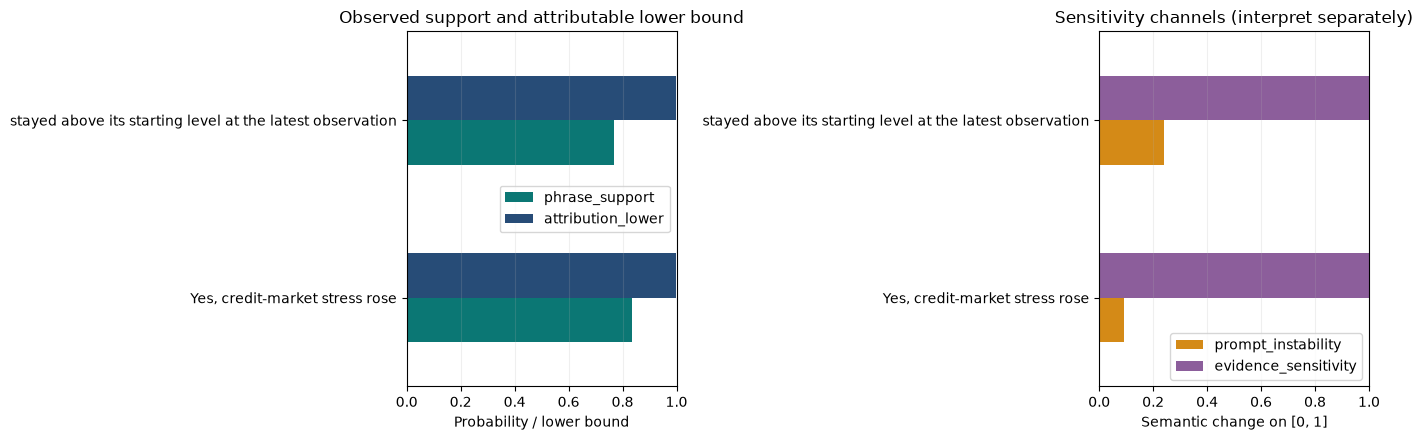

In [8]:
plot_data = claims.set_index("claim")[["phrase_support", "attribution_lower", "prompt_instability", "evidence_sensitivity"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_data[["phrase_support", "attribution_lower"]].plot.barh(ax=axes[0], color=["#0b7774", "#274c77"])
axes[0].set_title("Observed support and attributable lower bound")
axes[0].set_xlim(0, 1); axes[0].set_xlabel("Probability / lower bound"); axes[0].set_ylabel("")
plot_data[["prompt_instability", "evidence_sensitivity"]].plot.barh(ax=axes[1], color=["#d48a17", "#8c5e9b"])
axes[1].set_title("Sensitivity channels (interpret separately)")
axes[1].set_xlim(0, 1); axes[1].set_xlabel("Semantic change on [0, 1]"); axes[1].set_ylabel("")
for ax in axes: ax.grid(axis="x", alpha=.2)
plt.tight_layout()


## 5. Visualize the stochastic semantic evidence graph

The graph preserves sources and claims as separate nodes. An evidence-to-claim edge stores the measured relation law; claim nodes then compose into the answer. This makes it possible to locate a governance concern without collapsing every uncertainty source into one score.

,node_id,node_type,value,source_id,uri,authority_class
0,query,query,Based only on the supplied time-series evidenc...,,,
1,answer,answer,"Yes, credit‑market stress rose and stayed abov...",,,
2,passage:credit-timeseries-csv,evidence_passage,,credit-timeseries-csv,credit_market_timeseries.csv,unclassified
3,claim:1,answer_claim,"Yes, credit‑market stress rose",,,
4,claim:2,answer_claim,stayed above its starting level at the latest ...,,,


,source,target,edge_type,measurement_status
0,query,answer,conditions_generation,
1,passage:credit-timeseries-csv,claim:1,claim_evidence_relation,measured_uncalibrated
2,passage:credit-timeseries-csv,claim:2,claim_evidence_relation,measured_uncalibrated
3,claim:1,answer,composes,
4,claim:2,answer,composes,


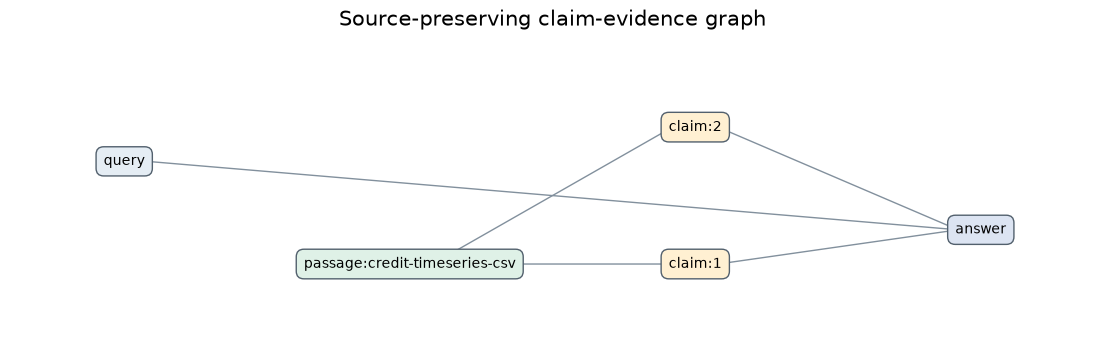

In [9]:
graph = result["semantic_evidence_graph"]
nodes = pd.DataFrame(graph["nodes"])
edges = pd.DataFrame(graph["edges"])
display(nodes.fillna(""))
display(edges[[column for column in ["source", "target", "edge_type", "measurement_status"] if column in edges]].fillna(""))

# A dependency-free graph drawing with fixed layers: evidence → claims → answer.
source_ids = nodes.loc[nodes.node_type == "evidence_passage", "node_id"].tolist()
claim_ids = nodes.loc[nodes.node_type == "answer_claim", "node_id"].tolist()
positions = {"query": (0, 1), "answer": (3, .5)}
positions.update({node: (1, i + .25) for i, node in enumerate(source_ids)})
positions.update({node: (2, i + .25) for i, node in enumerate(claim_ids)})
fig, ax = plt.subplots(figsize=(14, max(4, 1.6 * max(len(source_ids), len(claim_ids)))))
for _, edge in edges.iterrows():
    if edge.source in positions and edge.target in positions:
        x1, y1 = positions[edge.source]; x2, y2 = positions[edge.target]
        ax.annotate("", xy=(x2-.08, y2), xytext=(x1+.08, y1), arrowprops={"arrowstyle": "->", "color": "#82909d"})
for node_id, (x, y) in positions.items():
    node_type = nodes.loc[nodes.node_id == node_id, "node_type"].iloc[0]
    color = {"query": "#e5edf4", "evidence_passage": "#dff1e7", "answer_claim": "#fff0d2", "answer": "#dce4f2"}.get(node_type, "#eee")
    ax.text(x, y, node_id, ha="center", va="center", bbox={"boxstyle": "round,pad=.55", "facecolor": color, "edgecolor": "#52606d"})
ax.set_xlim(-.4, 3.4); ax.set_ylim(-.4, max([p[1] for p in positions.values()]) + .6); ax.axis("off")
ax.set_title("Source-preserving claim-evidence graph", fontsize=15, pad=14)
plt.show()


## 6. Use Verity in LangChain or LangGraph

Install `langchain-core` if it is not already available. The small adapter below is self-contained so this public notebook does not depend on private server source. It returns the complete result rather than reducing it to a single score, allowing downstream policy code to inspect the relevant gates. The packaged BeliefLens SDK exposes the equivalent `belieflens.integrations.langchain.VerityRunnable`.

In [ ]:
try:
    from langchain_core.runnables import Runnable
except ImportError:
    Runnable = object  # The direct HTTP example still works without LangChain.

class VerityRunnable(Runnable):
    def __init__(self, base_url=BASE_URL, auto_retrieve=True):
        self.base_url, self.auto_retrieve = base_url, auto_retrieve

    def invoke(self, value, config=None, **kwargs):
        prompt = value["prompt"] if isinstance(value, dict) else str(value)
        evidence = value.get("evidence", []) if isinstance(value, dict) else []
        payload = {"prompt": prompt, "evidence": evidence, "auto_retrieve": self.auto_retrieve and not evidence}
        with httpx.Client(base_url=self.base_url, timeout=180) as client:
            response = client.post("/v1/seg/chat", json=payload)
            response.raise_for_status()
            return response.json()

verity_node = VerityRunnable()
# One deliberate live call:
# chain_result = verity_node.invoke({"prompt": "What factors make credit markets fragile?"})


## 7. Trace the request with OpenTelemetry and Jaeger

BeliefLens propagates W3C trace context and exports service spans over OTLP. The API returns `X-BeliefLens-Trace-Id` and, when configured, `X-BeliefLens-Trace-Url`. The Jaeger browser at [traces.belieflens.org](https://traces.belieflens.org/) is restricted to authorized operators because it contains cross-user operational metadata. Public callers can provide the trace ID when reporting a problem. Request bodies, evidence, answers, and credentials are not captured as span attributes by default.

In [10]:
trace = {
    "trace_id": result.get("trace_id"),
    "operator_trace_url": trace_url or (f"https://traces.belieflens.org/trace/{result.get('trace_id')}" if result.get("trace_id") else None),
}
pd.Series(trace, name="OpenTelemetry trace")


trace_id                               de79e0e8f4d39a4eaddc52e506b662cd
operator_trace_url    https://traces.belieflens.org/trace/de79e0e8f4...
Name: OpenTelemetry trace, dtype: str

## Next steps

- Read the complete [public API guide](../../../../docs/PUBLIC_VERITY_API.md).
- Try the browser interface at [demo.belieflens.org/verity](https://demo.belieflens.org/verity).
- Request a workspace key at [demo.belieflens.org/signup](https://demo.belieflens.org/signup) for private benchmarks, calibrated validation, configurable studies, and higher governed limits.
- Read the [SSEG preprint](https://belieflens.org/assets/belieflens-stochastic-evidence-graphs-preprint.pdf) for the graph factorization, uncertainty channels, and governance construction.